## Final Assignment 

 For the obligatory assignment, you will use what you learned so far. The task is to code the solutions for the exercises, as well as edit the markdown cells underneath them, reporting  your choices, findings, and interpretations.

## A random protein dataset
You will work with a new randomly generated dataset called `mice_dataset.csv`. There is a cell with the code to set up the dataset, but be careful to only run that code once, otherwise you will overwrite your previous dataset, and your conclusions and results might not be reliable anymore.

## The goal

The evaluation __is not__ related to the results of your analysis. We are not looking for p-values or coefficients.
We will evaluate if: 
1. you can deliver a notebook that can run without `error`. 
2. you are applying the right tools. 
3. you can report your reasoning clearly.

## How to deliver
On GitHub, create a repository and invite us (HenriChap, JM-Godoy, hbarsnes) to contribute, so that we can evaluate.
Remember to set the visibility of your repo to `private` and write a `README.md` file.

---
### Setting up the exercise (generating random data)

Run the code below __only once__ to start your assignment.

Suggestion: comment out the code using `#` to make sure it won't run again.


In [6]:
#from random_dataset_generator import save_random_mice_dataset

#df = save_random_mice_dataset()

### Loading resources needed
Load all packages and modules needed. A nice way to keep track of the packages is adding them app along you are using them.

In [7]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.formula.api as smf

if not pathlib.Path("figures").exists():
    pathlib.Path("figures").mkdir()

sns.set_theme(style="whitegrid", context="notebook")

### Reading the file

Load the `mice_dataset.csv`.

In [8]:
data_folder_path = pathlib.Path ("..", "Final_Assignment","mice_dataset.csv") 
df = pd.read_csv(data_folder_path)
df.head()

,ID,Sex,Group,Weight(g),Age(weeks),Protein1,Protein2,Protein3,Protein4,Protein5,Protein6
0,Mice001,F,Control,24.991485,28.0,87.470986,145.572388,19.542352,977.994262,184.939206,223.871958
1,Mice002,M,Treatment,29.598742,34.0,103.181890,233.686016,NaN,334.015484,247.919290,405.974712
2,Mice003,F,Treatment,20.745661,30.0,82.089572,147.438270,NaN,797.238531,177.627953,326.103146
3,Mice004,M,Control,27.602722,27.0,105.358525,142.436325,NaN,820.147673,222.082639,235.719952
4,Mice005,F,Treatment,23.012260,31.0,88.398401,196.417504,NaN,45.059788,209.557178,318.914550


Pathlib is a module that is used when working with folder and reading files. It helps ensure that the file paths are formatted correctly and checks if the path exist or not, instead of writing file address as a plain text string in my coding. in line 1, i wrote ("..", "Final_Assignment","mice_dataset.csv"), even tho the file of interest is the mice dataset, but writing the folder too helps to locate it eaiser than writing only the dataset. I encountered an error where the file was not found , that`s why i choose to input it like so. "df.head ()" is a function that shows the first 5 rows of the dataframe. This is useful to get a quick overview of the data and see if its loaded correctly. 

### Describe the data 

In [9]:
df.describe()

,Weight(g),Age(weeks),Protein1,Protein2,Protein3,Protein4,Protein5,Protein6
count,138.000000,137.00000,138.000000,137.000000,27.000000,137.000000,138.000000,138.000000
mean,24.784582,30.10219,108.563398,159.335186,28.248701,492.518990,225.719706,311.120211
std,3.830300,2.49495,14.928933,27.506250,5.474753,283.020030,24.786657,51.246307
min,17.154252,26.00000,76.663634,94.432761,17.983362,18.557439,164.351776,190.409751
25%,21.471427,28.00000,96.412762,142.158117,25.120396,258.174400,209.834959,274.775324
50%,24.724618,30.00000,110.001274,157.064400,27.918421,513.281828,223.516257,314.082957
75%,28.506990,32.00000,120.250872,179.119575,32.471382,704.388769,243.549884,350.780864
max,32.001276,34.00000,139.926816,233.686016,36.552499,995.883561,284.571094,408.751484


The code i chose to run provides a statistical summary of the numbered variables in the dataset rather than using df.info (which gives information about the structure of the dataset). So now i can understand the distribution and range of the data.
Count: measures the sample size. The total number of valid observations and since some columns have lower count than others, that means some values are missing. This is very visible for protein3 where count is 27 (i`ll inspect this later). 
Mean: The average value. The number gives an overall general value of each category (weight, age etc.).
Std (Standard deviation): Tells me how far the value strays from eachother. so a low std means that the data are clustered to an average point, but a high std means the values are widely spread out (spread/dispersion).
Minimum: tells me the lowest data value recorded in each column.
25% (1st Quartile): The numerical value here shows that 25% of the observations fall below it (the value i mean) example, 25% of the weight recorded falls below 21.47 grams. 
50% (2nd Quartile): Same concept, but tells the exact middle point the data when sorted from lowest to highest, so half are below this numerical value, while the other half is above. 
75% (3rd Quartile): Same gist, 75% of all observations fall below this numerical value.
Maximum: Tells me the highest data value recorded in each column.


### Inspect and clean your data 

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          140 non-null    str    
 1   Sex         137 non-null    str    
 2   Group       139 non-null    str    
 3   Weight(g)   138 non-null    float64
 4   Age(weeks)  137 non-null    float64
 5   Protein1    138 non-null    float64
 6   Protein2    137 non-null    float64
 7   Protein3    27 non-null     float64
 8   Protein4    137 non-null    float64
 9   Protein5    138 non-null    float64
 10  Protein6    138 non-null    float64
dtypes: float64(8), str(3)
memory usage: 14.4 KB


In [11]:
df.isnull().sum()

ID              0
Sex             3
Group           1
Weight(g)       2
Age(weeks)      3
Protein1        2
Protein2        3
Protein3      113
Protein4        3
Protein5        2
Protein6        2
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.drop(columns = ["Protein3"]).dropna(axis = "index")


,ID,Sex,Group,Weight(g),Age(weeks),Protein1,Protein2,Protein4,Protein5,Protein6
0,Mice001,F,Control,24.991485,28.0,87.470986,145.572388,977.994262,184.939206,223.871958
1,Mice002,M,Treatment,29.598742,34.0,103.181890,233.686016,334.015484,247.919290,405.974712
2,Mice003,F,Treatment,20.745661,30.0,82.089572,147.438270,797.238531,177.627953,326.103146
3,Mice004,M,Control,27.602722,27.0,105.358525,142.436325,820.147673,222.082639,235.719952
4,Mice005,F,Treatment,23.012260,31.0,88.398401,196.417504,45.059788,209.557178,318.914550
...,...,...,...,...,...,...,...,...,...,...
135,Mice136,F,Control,20.579871,31.0,84.029261,153.889688,596.317074,188.072118,307.990454
136,Mice137,M,Treatment,26.392027,28.0,105.396252,139.984073,71.344992,217.523685,375.985551
137,Mice138,M,Treatment,25.346787,32.0,118.901958,198.548741,653.903912,256.077616,307.333298
138,Mice139,F,Control,18.620937,28.0,108.951376,144.467482,344.752841,224.343790,272.399782


In [58]:
mice_clean = df.drop(columns = ["Protein3"]).dropna(axis = "index")

print(mice_clean)

          ID Sex      Group  Weight(g)  Age(weeks)    Protein1    Protein2  \
0    Mice001   F    Control  24.991485        28.0   87.470986  145.572388   
1    Mice002   M  Treatment  29.598742        34.0  103.181890  233.686016   
2    Mice003   F  Treatment  20.745661        30.0   82.089572  147.438270   
3    Mice004   M    Control  27.602722        27.0  105.358525  142.436325   
4    Mice005   F  Treatment  23.012260        31.0   88.398401  196.417504   
..       ...  ..        ...        ...         ...         ...         ...   
135  Mice136   F    Control  20.579871        31.0   84.029261  153.889688   
136  Mice137   M  Treatment  26.392027        28.0  105.396252  139.984073   
137  Mice138   M  Treatment  25.346787        32.0  118.901958  198.548741   
138  Mice139   F    Control  18.620937        28.0  108.951376  144.467482   
139  Mice140   M    Control  29.222933        32.0  125.098996  165.413577   

       Protein4    Protein5    Protein6  
0    977.994262  184.

In [67]:
print("protein3" in mice_clean.columns)
print(mice_clean.columns)

False
Index(['ID', 'Sex', 'Group', 'Weight(g)', 'Age(weeks)', 'Protein1', 'Protein2',
       'Protein4', 'Protein5', 'Protein6'],
      dtype='str')


In [59]:
mice_clean.to_csv("mice_clean.csv", index = False)

Data inspection and cleaning is where i can check for any missing values (NaNs), incorrect data types or duplicate entries. I typed in function df.info to get a quick summary of row counts, column names, data types and the non-null counts. As visible, the non-null count for column protein 3, is way lower than the total number of rows (entries). This informs me of all the NaN here. There are more missing data too in the other columns, so to get en exact count i used isnull.sum, which counts the exact missing values in each column. Since there is quite a lot of numerical data, i wanted to check if there weren`t any duplicated data and the results shows that there is none duplication in my dataframe. After inspection, i chose to clean the dataset by removing the rows and column protein3 with missing value. Since i saw that the column had 113 NaN, it is better to drop it from the dataframe than trying to impute all that missing data. Removing them will also preserve the integrity of the dataset and. Since only three rows had NaN, Removing them leaves me with 137 entries with complete observations without reducing the data considerably. All the "cleaning" part is done by using the method df.dropna/drop. Since i found the column names quite clarifying, i dont see the necessity to be changing them. I thought of only changing the protein names cause protein3 column is now removed and there are only 5 protein columns in the new dataframe, but refrained from doing this in case the numbers are significant. 
I also lastly saved the new dataframe as mice_clean and beforehand double checked if the columns with NaN was indeed removed by using the function print("protein3") which gave me the bool: False, indicating that Protein3 column is indeed successfully removed. 

### Understand the mice population.
Use table and plots to understand how is your data distributed.

In [60]:
numeric_column = "Weight(g)"
categorical_column = "Group"

print("Numeric summary for:", numeric_column)
print(mice_clean[numeric_column].describe())

print()
print("Counts for:", categorical_column)
print(mice_clean[categorical_column].value_counts())

Numeric summary for: Weight(g)
count    137.000000
mean      24.755756
std        3.829303
min       17.154252
25%       21.469971
50%       24.626554
75%       28.361215
max       32.001276
Name: Weight(g), dtype: float64

Counts for: Group
Group
Treatment    69
Control      68
Name: count, dtype: int64


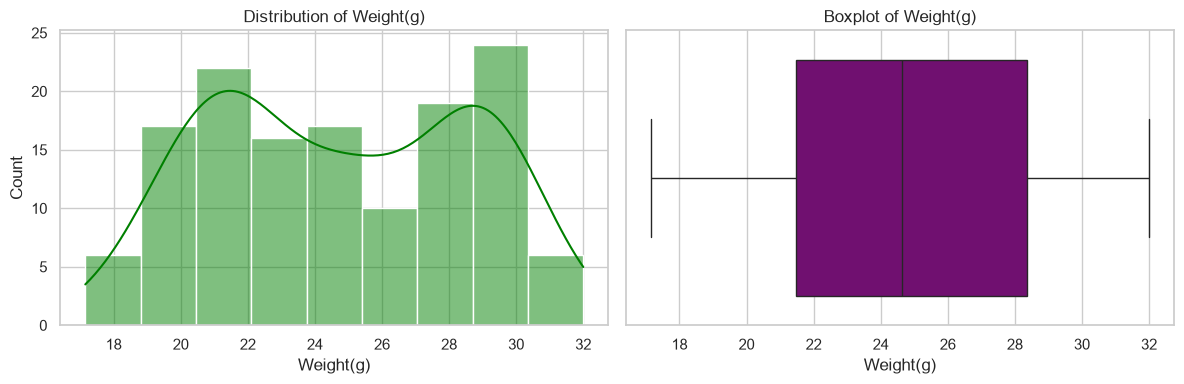

In [69]:
#Histogram and boxplot of mice weight in gram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=mice_clean, x=numeric_column, kde=True, ax=axes[0], color="green")
axes[0].set_title(f"Distribution of {numeric_column}")

sns.boxplot(data=mice_clean, x=numeric_column, ax=axes[1], color = "purple")
axes[1].set_title(f"Boxplot of {numeric_column}")
plt.tight_layout()
plt.savefig("figures/Distribution_data.png", dpi=300, bbox_inches="tight")
plt.show()

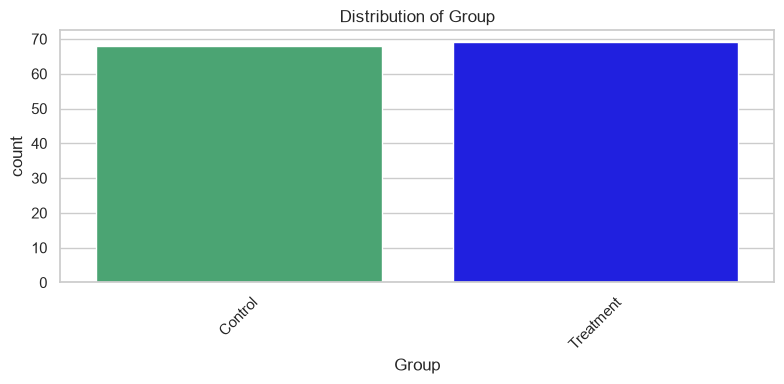

In [62]:
#countplot for group distribution of mice
custom_colors = {"Control":"mediumseagreen", "Treatment": "Blue"}
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=mice_clean, x=categorical_column, hue=categorical_column,
              palette = custom_colors, legend = False, ax=ax)
ax.set_title(f"Distribution of {categorical_column}")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figures/Distribution_group.png", dpi=300, bbox_inches="tight")
plt.show()



Before i plotted away, i chose to get a quick numerical summary for the variable weight and a summary count for group distribution, since the task here is to "understand the mice population" and not the proteins.
- Histogram: The figure shows a bimodal distribution, meaning there are two prominent peaks in the figure, one around 21-22g and the other around 29-30g. The data is fairly spread across the entire range without a heavy tail to one side, indicating a slightly symmetrid range depsite the double-peaked bins.
- Boxplot: The weight range from a min at 17g to a max at 32g. the interquartile range represented by the box, spans from approximately 21.5g (Q1) to 28g (Q3), covering the middle 50% of the mouse population. These can also be checked from the summary statistics i did earlier, where Q1 is 21.469≈21.5, Q3 is ≈28. Something else noticable is the mean and median being almost identical at 24.75 and 24.62, which indicates that the overall weight distribution is strongly symmetric around its center with no significant skewness. 
There is also no outliers which shows a consistency in the weight measurements and also confirms data quality that i didn`t have any entry errors or glitches fortunately.  

- Counter plot: Illustrates the ditribution of mice across the two categories under group. the sample is almost split evenly consisting of 68 mice in control group and 69 mice in the treatment group. This balanced group dispersion minimize potential bias in sampling and ensure a comparable group size for downstream statistical comparisons. 

### Explore the relationship between the proteins

Plot data to give you information about possible relationships between proteins.

In [91]:
print("all columns:", mice_clean.columns.tolist())
protein_cols = [col for col in mice_clean.columns if "protein" in col.lower()]
print("Found protein columns:", protein_cols)
corr = mice_clean[protein_cols].corr()
print("\nCorrelation matrix (rounded):")
print(corr.round(2))

all columns: ['ID', 'Sex', 'Group', 'Weight(g)', 'Age(weeks)', 'Protein1', 'Protein2', 'Protein4', 'Protein5', 'Protein6']
Found protein columns: ['Protein1', 'Protein2', 'Protein4', 'Protein5', 'Protein6']

Correlation matrix (rounded):
          Protein1  Protein2  Protein4  Protein5  Protein6
Protein1      1.00     -0.06     -0.01      0.88      0.16
Protein2     -0.06      1.00      0.10      0.36      0.21
Protein4     -0.01      0.10      1.00      0.05     -0.12
Protein5      0.88      0.36      0.05      1.00      0.25
Protein6      0.16      0.21     -0.12      0.25      1.00


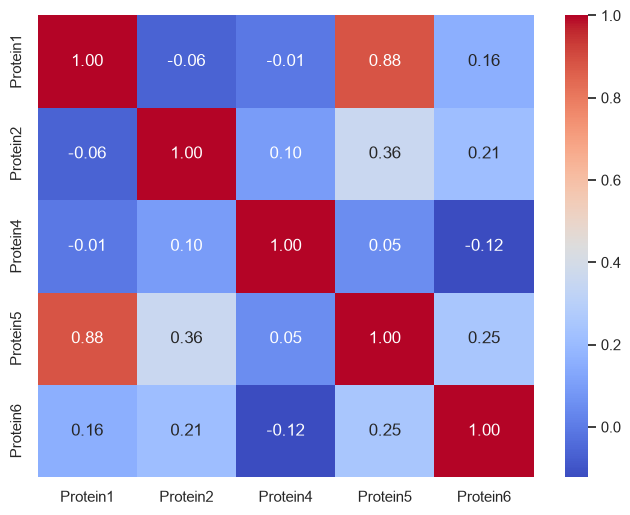

In [90]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot= True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.savefig("figures/correlation_matrix_heatmap.png", dpi = 300)
plt.show()

Before i can create a plot, i had to filter the data so that only the Protein columns were included in the heatmap, and not weight and age since they`re also numerical. This is so i didnt need to change the whole dataframe. After the protein columns were specifically selected, time for heatmap plotting.  
Correlation Heatmap of the proteins:
The correlation heatmap displays the different proteins relation to one another. 
A prominent finding is the strong positive correlation between Protein 1 and Protein 5 (r=0.88), indicating a shared regulatory mechanism or expression pathway. Protein 2 and Protein 5 exhibit a mild positive association to eachother (r=0.36). In contrast, Protein 4 displays negative linear correlation with all other proteins (r ranging from -0.12 to 0.10), suggesting its expression operates independently within this mice dataframe. Overall, the heatmap shows that while most proteins exhibit very low co-expression, Protein 1 and Protien 5 stand out as strongly co-regulated.

### Choose two proteins and explore the relationship between them.

After plotting the data, use linear regression to understand the relationship of those two proteins.

In [93]:
quantitative_x = "Protein1"
quantitative_y = "Protein5"
group_column = "group"

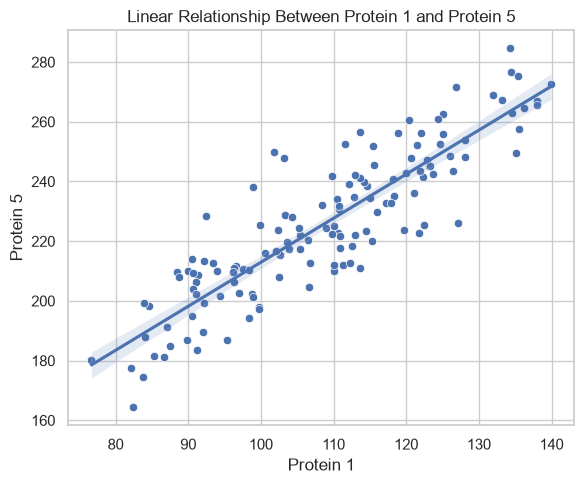

In [97]:
fig, ax = plt.subplots (figsize = (6,5))
sns.scatterplot(data=mice_clean, x = quantitative_x, y= quantitative_y, ax= ax)
sns.regplot(data=mice_clean, x = quantitative_x, y= quantitative_y, scatter = False, ax=ax)
ax.set_title ("Linear Relationship Between Protein 1 and Protein 5")
ax.set_xlabel ("Protein 1")
ax.set_ylabel ("Protein 5")
plt.tight_layout()
plt.savefig("figures/two_variables_scatterplot.png", dpi = 300)
plt.show()

### Choose a protein and test if there is a difference between any non-protein variable

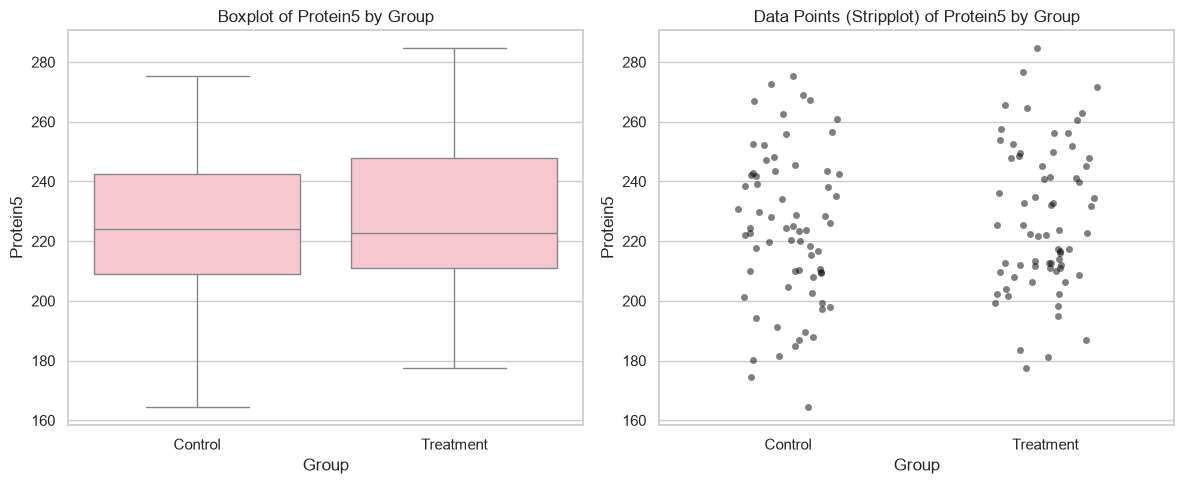

--- Summary Statistics for Protein5 by Group ---
           count    mean    std  median
Group                                  
Control       68  224.24  25.66  224.06
Treatment     69  227.28  24.16  222.68

--- Independent t-test for Protein5 ---
t-statistic: -0.7135
p-value:     4.7674e-01


In [100]:
#Boxplot and Stripplot with summary statistics and a Two-sample t-test (p-value)
group_col = "Group"
target_protein = "Protein5"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=mice_clean, x=group_col, y=target_protein, ax=axes[0], color="pink")
axes[0].set_title(f"Boxplot of {target_protein} by {group_col}")

sns.stripplot(data=mice_clean, x=group_col, y=target_protein, ax=axes[1], color="black", alpha=0.5, jitter=0.2)
axes[1].set_title(f"Data Points (Stripplot) of {target_protein} by {group_col}")

plt.tight_layout()
plt.savefig("figures/protein5_group_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"--- Summary Statistics for {target_protein} by {group_col} ---")
print(mice_clean.groupby(group_col)[target_protein].agg(["count", "mean", "std", "median"]).round(2))

control_vals = mice_clean[mice_clean[group_col] == "Control"][target_protein]
treatment_vals = mice_clean[mice_clean[group_col] == "Treatment"][target_protein]

t_stat, p_val = stats.ttest_ind(control_vals, treatment_vals)

print(f"\n--- Independent t-test for {target_protein} ---")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.4e}")



- Boxplot: Distribution comparison between the control and treatment group. There is very little difference observed in the figures.
- Stripplot: Individual mouse datapoints, where each dot represent one mouse in both group. 
- Summary statistics and statistical test (two sample t-test).

A combined boxplot and stripplot to visualize, was generated to test for differences in Protein 5 levels between the control (n=68) and treatment (n=69) groups.
The mean protein 5 level is 224.24 in the control group and 227.28 in the treatment group, median were similarily close with 224.06 and 222.68 respectively each.
An independent two-sample t-test revealed no statistically significant difference in protein 5 levels between the two conditions (t = 0.7135, p = 0.477). 
In conclusion, the treatment condition did not significantly alter the expression level of protein 5 relative to the control group. 